In [ ]:
# ====================================================================
# CELL 1: Install packages and imports
# ====================================================================
!pip -q install imbalanced-learn xgboost==1.7.6 shap mord

import warnings, re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTENC
import xgboost as xgb
import shap
import mord

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 6.0 MB/s eta 0:00:00


In [ ]:
# ====================================================================
# CELL 2: Load data from Google Drive
# ====================================================================
from google.colab import drive
drive.mount('/content/drive')

# 👉 Change this path to where your file is in Drive
CSV_PATH = "/content/drive/MyDrive/SMA.csv"

df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()

Mounted at /content/drive
(1029, 15)


,Q1_Gender,Q2_Living_Area,Q3_Maritial_Status,SMAQ1,SMAQ2,SMAQ3,SMAQ4,SMAQ5,SMAQ6,SMAQ7,SMAQ8,SMAQ9,SMAQ10,SMA_Scale_value,SMA_Scale (Class_Lebel)
0,1,1,2,4,5,1,3,5,2,2,4,5,3,34,2
1,1,1,2,3,2,1,5,5,1,1,2,5,1,26,2
2,2,1,2,3,2,1,1,1,1,1,1,1,1,13,1
3,1,2,2,2,5,5,2,3,1,3,4,4,1,30,2
4,1,1,2,1,4,3,1,2,1,1,1,1,1,16,1


In [ ]:
# ====================================================================
# CELL 3: Data exploration
# ====================================================================
df.info()
print("\nMissing values per column:\n", df.isnull().sum())
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1029 entries, 0 to 1028
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Q1_Gender                1029 non-null   int64
 1   Q2_Living_Area           1029 non-null   int64
 2   Q3_Maritial_Status       1029 non-null   int64
 3   SMAQ1                    1029 non-null   int64
 4   SMAQ2                    1029 non-null   int64
 5   SMAQ3                    1029 non-null   int64
 6   SMAQ4                    1029 non-null   int64
 7   SMAQ5                    1029 non-null   int64
 8   SMAQ6                    1029 non-null   int64
 9   SMAQ7                    1029 non-null   int64
 10  SMAQ8                    1029 non-null   int64
 11  SMAQ9                    1029 non-null   int64
 12  SMAQ10                   1029 non-null   int64
 13  SMA_Scale_value          1029 non-null   int64
 14  SMA_Scale (Class_Lebel)  1029 non-null   int64
dtypes: i

,Q1_Gender,Q2_Living_Area,Q3_Maritial_Status,SMAQ1,SMAQ2,SMAQ3,SMAQ4,SMAQ5,SMAQ6,SMAQ7,SMAQ8,SMAQ9,SMAQ10,SMA_Scale_value,SMA_Scale (Class_Lebel)
count,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000,1029.000000
mean,1.364431,1.290573,1.939747,3.926142,3.335277,2.743440,2.182702,2.898931,2.389699,2.029155,2.491740,3.204082,1.396501,26.597668,1.821186
std,0.481504,0.454248,0.238070,1.155425,1.262035,1.380192,1.239607,1.412661,1.373998,1.191378,1.379103,1.364910,0.866714,8.128553,0.537593
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,1.000000
25%,1.000000,1.000000,2.000000,3.000000,3.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,21.000000,2.000000
50%,1.000000,1.000000,2.000000,4.000000,3.000000,3.000000,2.000000,3.000000,2.000000,2.000000,2.000000,3.000000,1.000000,26.000000,2.000000
75%,2.000000,2.000000,2.000000,5.000000,4.000000,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,4.000000,1.000000,32.000000,2.000000
max,2.000000,2.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,50.000000,3.000000


In [ ]:
# ====================================================================
# CELL 4: Prepare features and target
# ====================================================================
# Try to find the target column robustly
target_candidates = [c for c in df.columns if re.search(r"SMA_Scale.*Class.*", c, re.I)]
assert len(target_candidates) >= 1, "Target column not found. Check your CSV header."
TARGET_COL = target_candidates[0]
print("Using target column:", TARGET_COL)

# Basic value range checks (non-fatal)
for col in ['Q1_Gender','Q2_Living_Area','Q3_Maritial_Status']:
    if col in df.columns:
        bad = df[~df[col].isin([1,2])]
        if len(bad):
            print(f"Warning: {col} has values outside {{1,2}}. Rows:", len(bad))

# Ensure class labels are integers 1,2,3
df[TARGET_COL] = df[TARGET_COL].astype(int)

# Features = all except target (we do NOT use SMA_Scale_value for modeling)
drop_cols = [TARGET_COL]
if 'SMA_Scale_value' in df.columns:
    drop_cols.append('SMA_Scale_value')

X = df.drop(columns=drop_cols).copy()
y = df[TARGET_COL].copy()

print("Features:", list(X.columns))
print("Class distribution:\n", y.value_counts().sort_index())

Using target column: SMA_Scale (Class_Lebel)
Features: ['Q1_Gender', 'Q2_Living_Area', 'Q3_Maritial_Status', 'SMAQ1', 'SMAQ2', 'SMAQ3', 'SMAQ4', 'SMAQ5', 'SMAQ6', 'SMAQ7', 'SMAQ8', 'SMAQ9', 'SMAQ10']
Class distribution:
 SMA_Scale (Class_Lebel)
1    257
2    699
3     73
Name: count, dtype: int64


In [ ]:
# ====================================================================
# CELL 5: Train-test split
# ====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# ✅ Convert labels 1,2,3 → 0,1,2 (Required for XGBoost)
y_train = y_train - 1
y_test  = y_test  - 1

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class counts:\n", y_train.value_counts().sort_index())
print("Test class counts:\n", y_test.value_counts().sort_index())

Train: (823, 13) Test: (206, 13)
Train class counts:
 SMA_Scale (Class_Lebel)
0    206
1    559
2     58
Name: count, dtype: int64
Test class counts:
 SMA_Scale (Class_Lebel)
0     51
1    140
2     15
Name: count, dtype: int64


In [ ]:
# ====================================================================
# CELL 6: SMOTE balancing
# ====================================================================
# Identify categorical indices by column names (robust)
cat_cols = [c for c in X_train.columns if c in ['Q1_Gender','Q2_Living_Area','Q3_Maritial_Status']]
cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]
print("Categorical columns:", cat_cols, "-> indices:", cat_idx)

sm = SMOTENC(categorical_features=cat_idx, random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts().sort_index().to_dict())
print("After :", y_train_bal.value_counts().sort_index().to_dict())

Categorical columns: ['Q1_Gender', 'Q2_Living_Area', 'Q3_Maritial_Status'] -> indices: [0, 1, 2]
Before: {0: 206, 1: 559, 2: 58}
After : {0: 559, 1: 559, 2: 559}


In [ ]:
# ====================================================================
# CELL 7: Evaluation function
# ====================================================================
def evaluate_model(clf, X_test, y_test, name="Model", proba_method="predict_proba"):
    y_pred = clf.predict(X_test)
    print(f"\n=== {name} — Classification Report ===")
    print(classification_report(y_test, y_pred, digits=4))

    fig, ax = plt.subplots(figsize=(4,4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
    ax.set_title(f"{name} — Confusion Matrix")
    plt.show()

    # ROC-AUC (OvR) if we have probabilities
    if hasattr(clf, proba_method):
        y_score = getattr(clf, proba_method)(X_test)
        if isinstance(y_score, list):  # some libs return list
            y_score = y_score[0]
        # Ensure correct shape for binary/proba or multiclass
        classes = sorted(np.unique(y_test))
        y_bin = label_binarize(y_test, classes=classes)
        try:
            macro_auc = roc_auc_score(y_bin, y_score, average="macro", multi_class='ovr')
            micro_auc = roc_auc_score(y_bin, y_score, average="micro", multi_class='ovr')
            print(f"{name} — Macro AUC: {macro_auc:.4f} | Micro AUC: {micro_auc:.4f}")

            # Global ROC overview
            RocCurveDisplay.from_predictions(y_bin.ravel(), np.asarray(y_score).ravel())
            plt.title(f"{name} — ROC (flattened OvR)")
            plt.show()
        except Exception as e:
            print("AUC calculation skipped:", e)


=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

           0     0.9623    1.0000    0.9808        51
           1     1.0000    0.9143    0.9552       140
           2     0.6000    1.0000    0.7500        15

    accuracy                         0.9417       206
   macro avg     0.8541    0.9714    0.8953       206
weighted avg     0.9615    0.9417    0.9466       206



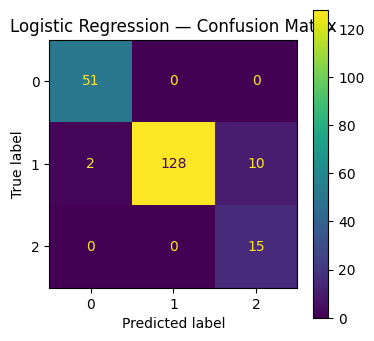

Logistic Regression — Macro AUC: 0.9984 | Micro AUC: 0.9961


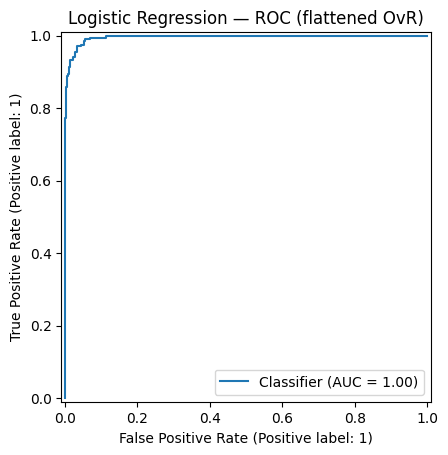

In [ ]:
# ====================================================================
# CELL 8: Logistic Regression baseline
# ====================================================================
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', multi_class='auto')
logreg.fit(X_train_bal, y_train_bal)
evaluate_model(logreg, X_test, y_test, name="Logistic Regression")


=== XGBoost (Nominal) — Classification Report ===
              precision    recall  f1-score   support

           0     0.8889    0.9412    0.9143        51
           1     0.9632    0.9357    0.9493       140
           2     0.8125    0.8667    0.8387        15

    accuracy                         0.9320       206
   macro avg     0.8882    0.9145    0.9008       206
weighted avg     0.9339    0.9320    0.9326       206



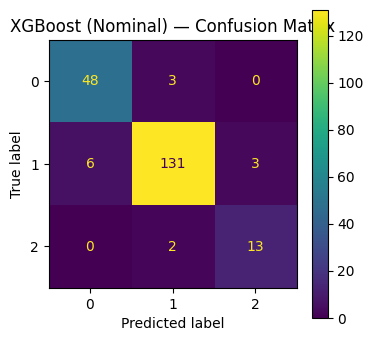

XGBoost (Nominal) — Macro AUC: 0.9896 | Micro AUC: 0.9922


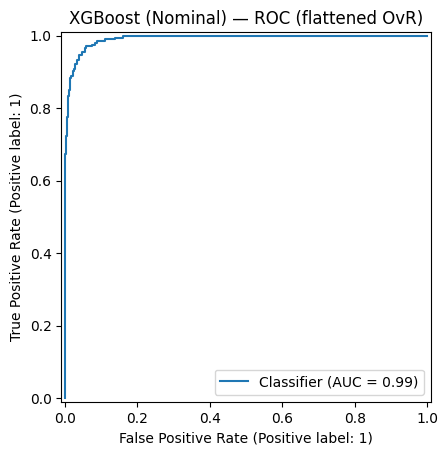

In [ ]:
# ====================================================================
# CELL 9: XGBoost nominal (no monotone constraints)
# ====================================================================
xgb_nominal = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=4,
    learning_rate=0.07,
    n_estimators=300,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    tree_method="hist"
)
xgb_nominal.fit(X_train_bal, y_train_bal)
evaluate_model(xgb_nominal, X_test, y_test, name="XGBoost (Nominal)")


=== Ordinal Logistic (MORD) — Classification Report ===
              precision    recall  f1-score   support

           0     0.9808    1.0000    0.9903        51
           1     1.0000    0.9214    0.9591       140
           2     0.6000    1.0000    0.7500        15

    accuracy                         0.9466       206
   macro avg     0.8603    0.9738    0.8998       206
weighted avg     0.9661    0.9466    0.9516       206



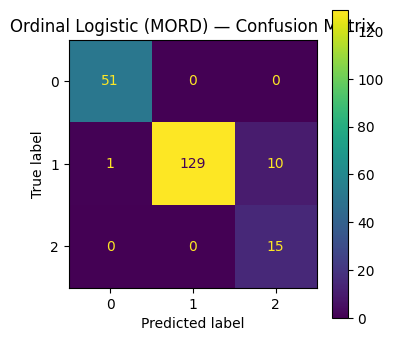

In [ ]:
# ====================================================================
# CELL 10: Ordinal Logistic Regression (MORD)
# ====================================================================
ord_logit = mord.LogisticAT(alpha=1.0)  # All-Threshold model
ord_logit.fit(X_train_bal.values, y_train_bal.values)

# Evaluate (no predict_proba in mord; we evaluate via hard predictions)
evaluate_model(ord_logit, X_test.values, y_test.values, name="Ordinal Logistic (MORD)", proba_method="_nope_")

Monotone vector: [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

=== XGBoost (Monotone) — Classification Report ===
              precision    recall  f1-score   support

           0     0.9020    0.9020    0.9020        51
           1     0.9565    0.9429    0.9496       140
           2     0.8235    0.9333    0.8750        15

    accuracy                         0.9320       206
   macro avg     0.8940    0.9261    0.9089       206
weighted avg     0.9333    0.9320    0.9324       206



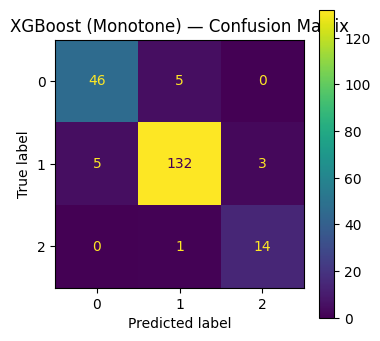

XGBoost (Monotone) — Macro AUC: 0.9851 | Micro AUC: 0.9886


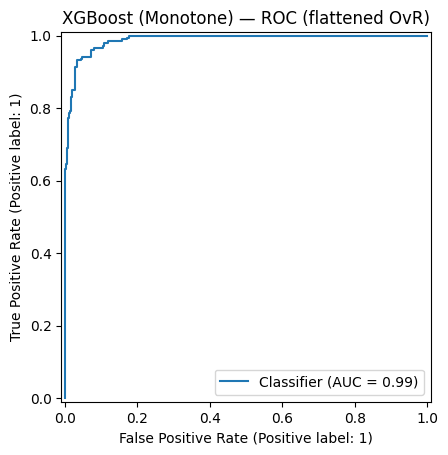

In [ ]:
# ====================================================================
# CELL 11: XGBoost with monotone constraints
# ====================================================================
# Build monotone constraints vector aligned with column order
mono = []
for c in X_train_bal.columns:
    if re.match(r"SMAQ\d+$", c):     # SMAQ1..SMAQ10
        mono.append(1)               # monotone increasing
    else:
        mono.append(0)               # no constraint for demos/etc.

print("Monotone vector:", mono)

xgb_monotone = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=4,
    learning_rate=0.05,
    n_estimators=400,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    monotone_constraints="(" + ",".join(map(str, mono)) + ")",
    random_state=42,
    tree_method="hist"
)
xgb_monotone.fit(X_train_bal, y_train_bal)
evaluate_model(xgb_monotone, X_test, y_test, name="XGBoost (Monotone)")


SHAP Analysis for High Addiction Class

Type of shap_values: <class 'numpy.ndarray'>
Outer shape: (206, 13, 3)
First element shape: (13, 3)

Extracted SHAP values shape for class 2: (206, 13)
X_shap shape: (206, 13)

✅ Generating SHAP summary plot...


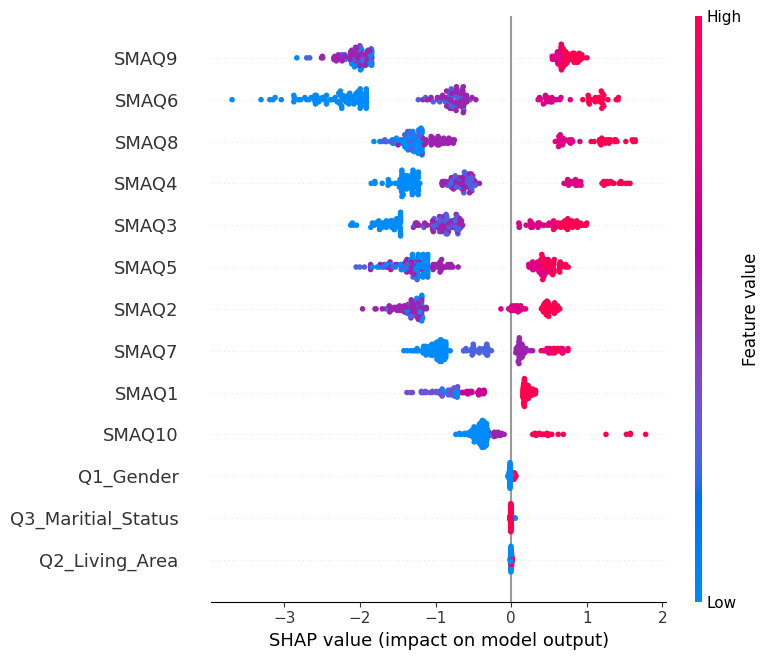


✅ Generating SHAP feature importance bar plot...


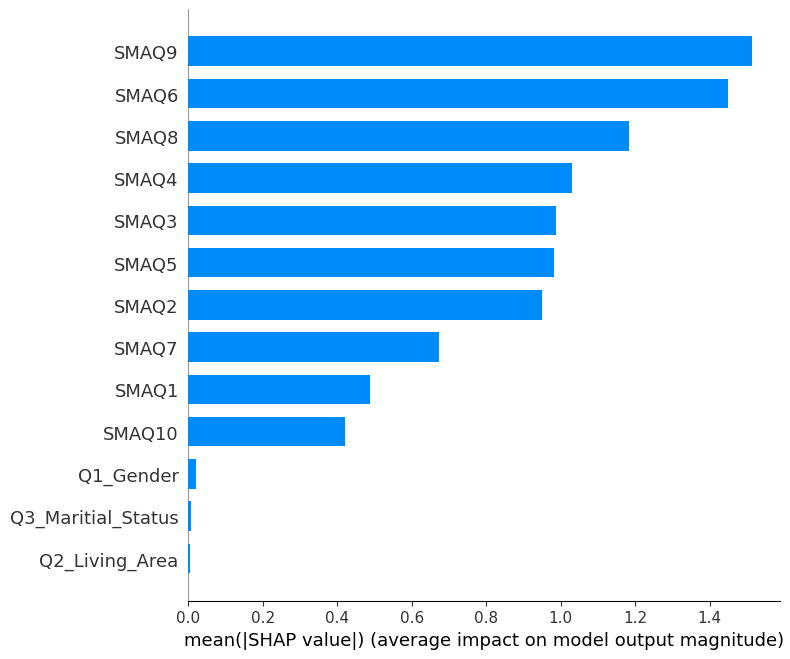


✅ Generating dependency plots for top 3 features...

Dependency plot for: SMAQ9


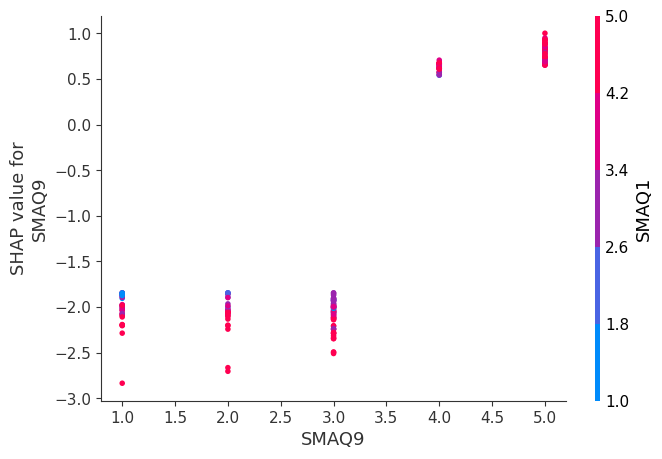


Dependency plot for: SMAQ6


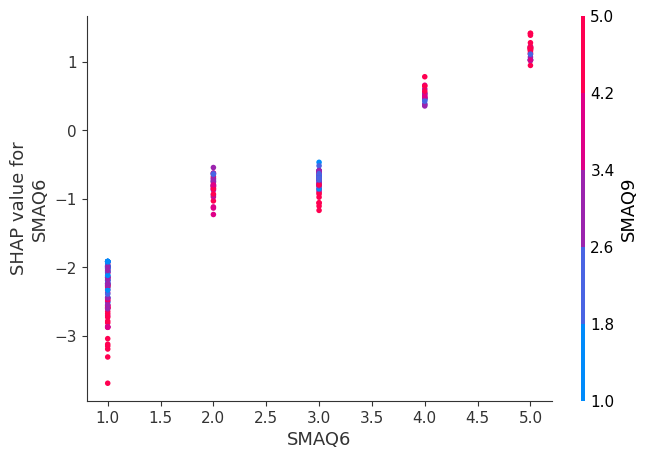


Dependency plot for: SMAQ8


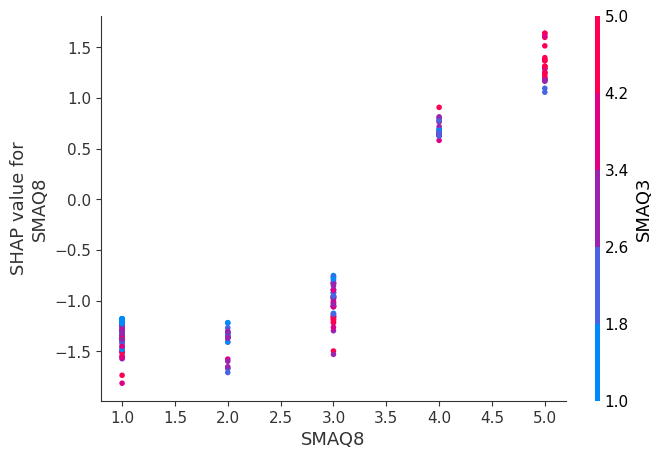


✅ SHAP Analysis complete!


In [ ]:
# ====================================================================
# CELL 12: SHAP Analysis (ACTUALLY FINAL FIX)
# ====================================================================
X_shap = X_test.copy()
if len(X_shap) > 300:
    X_shap = X_shap.sample(300, random_state=42)

# Use TreeExplainer
explainer = shap.TreeExplainer(xgb_monotone)
shap_values = explainer.shap_values(X_shap)

print(f"\n{'='*60}")
print(f"SHAP Analysis for High Addiction Class")
print(f"{'='*60}\n")

# Debug: Check the structure
print(f"Type of shap_values: {type(shap_values)}")
print(f"Outer shape: {shap_values.shape}")
print(f"First element shape: {shap_values[0].shape}")

# ✅ CORRECT EXTRACTION:
# shap_values shape is (n_samples, n_features, n_classes)
# We need (n_samples, n_features) for class 2

high_class = 2

# Extract SHAP values for class 2 across all samples and features
shap_values_class2 = shap_values[:, :, high_class]

print(f"\nExtracted SHAP values shape for class {high_class}: {shap_values_class2.shape}")
print(f"X_shap shape: {X_shap.shape}")

# Convert to numpy for compatibility
X_shap_array = X_shap.values
feature_names = X_shap.columns.tolist()

# Verify shapes match
assert shap_values_class2.shape == X_shap_array.shape, \
    f"Shape mismatch! SHAP: {shap_values_class2.shape}, X: {X_shap_array.shape}"

# ✅ GLOBAL SUMMARY PLOT (beeswarm)
print("\n✅ Generating SHAP summary plot...")
shap.summary_plot(
    shap_values_class2,
    X_shap_array,
    feature_names=feature_names,
    show=True
)

# ✅ BAR PLOT (feature importance)
print("\n✅ Generating SHAP feature importance bar plot...")
shap.summary_plot(
    shap_values_class2,
    X_shap_array,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

# ✅ DEPENDENCY PLOTS for top features
print("\n✅ Generating dependency plots for top 3 features...")
mean_abs_shap = np.abs(shap_values_class2).mean(axis=0)
top_features_idx = np.argsort(mean_abs_shap)[-3:][::-1]

for idx in top_features_idx:
    feature_name = feature_names[idx]
    print(f"\nDependency plot for: {feature_name}")
    shap.dependence_plot(
        idx,
        shap_values_class2,
        X_shap_array,
        feature_names=feature_names,
        show=True
    )

print("\n✅ SHAP Analysis complete!")


🔥 SHAP ANALYSIS — MONOTONIC XGBOOST (HIGH-CLASS INTERPRETATION)

📌 Building TreeExplainer...
✅ TreeExplainer ready!

📌 Computing SHAP values (this may take a few seconds)...
✅ SHAP values computed!

📌 SHAP Output Structure:
Type: <class 'numpy.ndarray'>
Shape: (206, 13, 3)

📌 Extracting SHAP values for HIGH ADDICTION CLASS = 2
✅ Extracted shape: (206, 13)
✅ X_shap shape   : (206, 13)

🎨 Generating SHAP Beeswarm Plot...


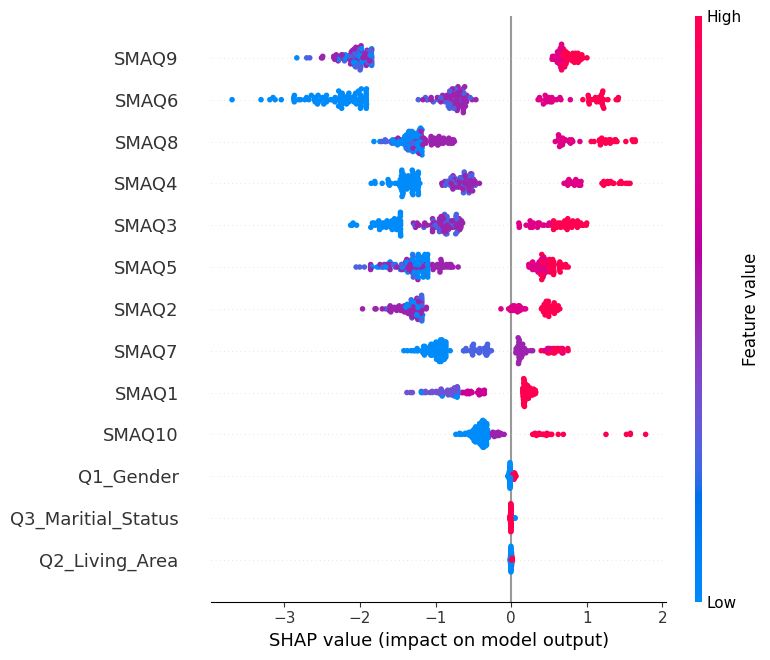


🎨 Generating SHAP Bar Plot...


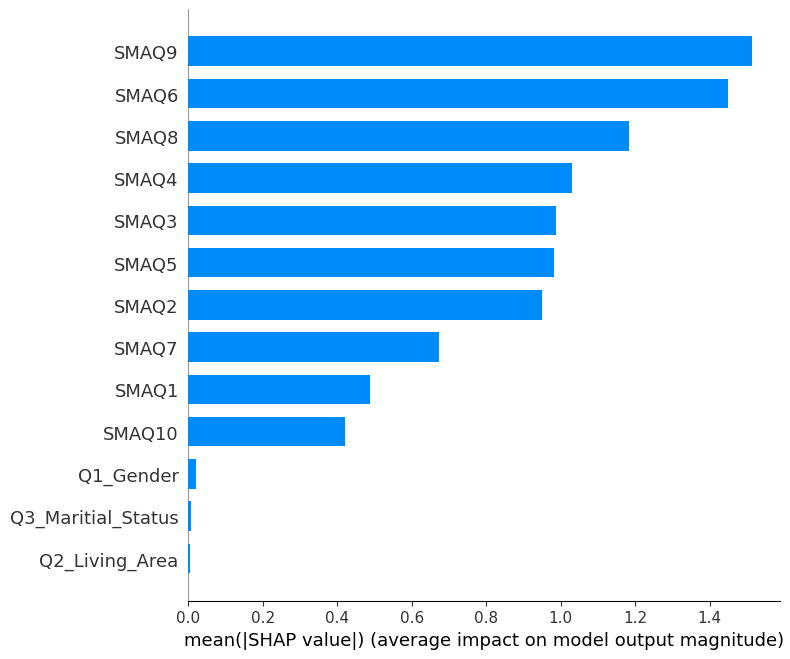


🔍 Identifying top 3 influential features...

✅ Top 3 Features:
   - SMAQ9 (index 11)
   - SMAQ6 (index 8)
   - SMAQ8 (index 10)

🎨 Generating Dependency Plots...

📌 Dependency Plot → SMAQ9


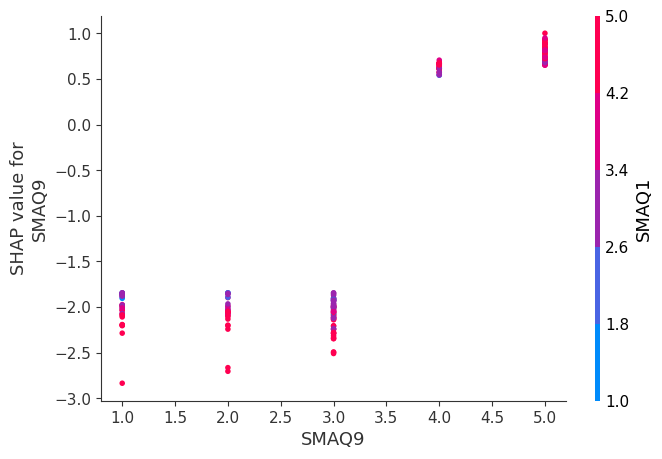


📌 Dependency Plot → SMAQ6


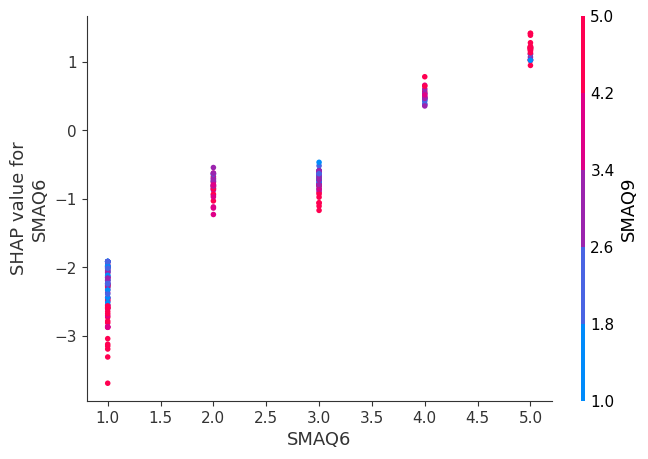


📌 Dependency Plot → SMAQ8


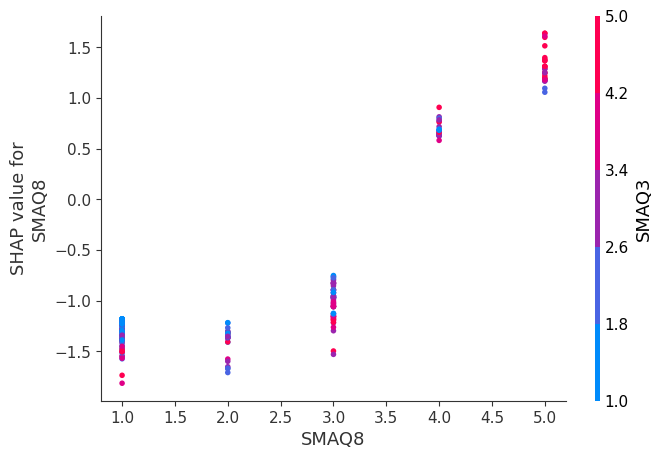


✅ SHAP ANALYSIS COMPLETE — YOU CAN USE THESE PLOTS IN YOUR PAPER!


In [ ]:
# ====================================================================
# ✅ FINAL SHAP ANALYSIS CELL (POLISHED & RESEARCH-READY)
# ====================================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("🔥 SHAP ANALYSIS — MONOTONIC XGBOOST (HIGH-CLASS INTERPRETATION)")
print("="*80)

# --------------------------------------------------------------------
# ✅ STEP 1 — Sample X_test for faster SHAP
# --------------------------------------------------------------------
X_shap = X_test.copy()
if len(X_shap) > 300:
    X_shap = X_shap.sample(300, random_state=42)

X_shap_array = X_shap.values
feature_names = X_shap.columns.tolist()

# --------------------------------------------------------------------
# ✅ STEP 2 — Create TreeExplainer
# --------------------------------------------------------------------
print("\n📌 Building TreeExplainer...")
explainer = shap.TreeExplainer(xgb_monotone)

print("✅ TreeExplainer ready!")

# --------------------------------------------------------------------
# ✅ STEP 3 — Compute SHAP values
# --------------------------------------------------------------------
print("\n📌 Computing SHAP values (this may take a few seconds)...")
shap_values = explainer.shap_values(X_shap)

print("✅ SHAP values computed!")

# --------------------------------------------------------------------
# ✅ STEP 4 — Inspect SHAP output structure
# --------------------------------------------------------------------
print("\n📌 SHAP Output Structure:")
print("Type:", type(shap_values))
print("Shape:", np.array(shap_values).shape)

# --------------------------------------------------------------------
# ✅ STEP 5 — Extract SHAP for High Addiction Class (2)
# --------------------------------------------------------------------
high_class = 2  # since labels were shifted to 0,1,2

print(f"\n📌 Extracting SHAP values for HIGH ADDICTION CLASS = {high_class}")

# NEW SHAP: (n_samples, n_features, n_classes)
shap_values_class2 = shap_values[:, :, high_class]

print("✅ Extracted shape:", shap_values_class2.shape)
print("✅ X_shap shape   :", X_shap_array.shape)

# Validate shape match
assert shap_values_class2.shape == X_shap_array.shape, \
    "❌ SHAP values and input features shape mismatch!"


# ====================================================================
# ✅ STEP 6 — GLOBAL SUMMARY PLOTS
# ====================================================================

print("\n🎨 Generating SHAP Beeswarm Plot...")
shap.summary_plot(
    shap_values_class2,
    X_shap_array,
    feature_names=feature_names,
    show=True
)

print("\n🎨 Generating SHAP Bar Plot...")
shap.summary_plot(
    shap_values_class2,
    X_shap_array,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

# --------------------------------------------------------------------
# ✅ OPTIONAL — SAVE FIGURES FOR PAPER
# --------------------------------------------------------------------
save_figures = False  # ✅ change to True if you want files saved

if save_figures:
    plt.savefig("/content/drive/MyDrive/SHAP_summary_class2.png", dpi=300)
    print("\n📁 Saved: SHAP_summary_class2.png")


# ====================================================================
# ✅ STEP 7 — DEPENDENCE PLOTS FOR TOP FEATURES
# ====================================================================

print("\n🔍 Identifying top 3 influential features...")
mean_abs_shap = np.abs(shap_values_class2).mean(axis=0)
top_features_idx = np.argsort(mean_abs_shap)[-3:][::-1]

print("\n✅ Top 3 Features:")
for idx in top_features_idx:
    print(f"   - {feature_names[idx]} (index {idx})")


print("\n🎨 Generating Dependency Plots...")
for idx in top_features_idx:
    feature_name = feature_names[idx]
    print(f"\n📌 Dependency Plot → {feature_name}")
    shap.dependence_plot(
        idx,
        shap_values_class2,
        X_shap_array,
        feature_names=feature_names,
        show=True
    )


print("\n" + "="*80)
print("✅ SHAP ANALYSIS COMPLETE — YOU CAN USE THESE PLOTS IN YOUR PAPER!")
print("="*80)

In [ ]:
# ====================================================================
# ✅ PHASE 9 — Model Comparison Table
# ====================================================================

def get_metrics(clf, X_te, y_te, name):
    y_pred = clf.predict(X_te if not isinstance(X_te, np.ndarray) else X_te)
    rep = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
    macro_f1 = rep['macro avg']['f1-score']
    weighted_f1 = rep['weighted avg']['f1-score']
    acc = rep['accuracy']
    return pd.Series({"Model": name, "Accuracy": acc, "Macro_F1": macro_f1, "Weighted_F1": weighted_f1})

rows = []
rows.append(get_metrics(logreg, X_test, y_test, "Logistic Regression"))
rows.append(get_metrics(xgb_nominal, X_test, y_test, "XGBoost (Nominal)"))
rows.append(get_metrics(ord_logit, X_test.values, y_test.values, "Ordinal Logistic (MORD)"))
rows.append(get_metrics(xgb_monotone, X_test, y_test, "XGBoost (Monotone)"))

summary = pd.DataFrame(rows).sort_values("Macro_F1", ascending=False)
summary.reset_index(drop=True, inplace=True)

print("\n=== MODEL COMPARISON TABLE ===")
summary


=== MODEL COMPARISON TABLE ===


,Model,Accuracy,Macro_F1,Weighted_F1
0,XGBoost (Monotone),0.932039,0.908867,0.932401
1,XGBoost (Nominal),0.932039,0.900757,0.932562
2,Ordinal Logistic (MORD),0.946602,0.899800,0.951602
3,Logistic Regression,0.941748,0.895331,0.946605


In [ ]:
# ====================================================================
# ✅ PHASE 10 — 5-Fold Cross-Validation for Robustness
# ====================================================================

def cv_macro_f1(clf, X_tr, y_tr, name):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for tr_idx, va_idx in skf.split(X_tr, y_tr):
        Xtr, Xva = X_tr.iloc[tr_idx], X_tr.iloc[va_idx]
        ytr, yva = y_tr.iloc[tr_idx], y_tr.iloc[va_idx]
        clf_ = clf
        clf_.fit(Xtr, ytr)
        pred = clf_.predict(Xva)
        rep = classification_report(yva, pred, output_dict=True, zero_division=0)
        scores.append(rep['macro avg']['f1-score'])
    return name, np.mean(scores), np.std(scores)

print("\n=== CROSS-VALIDATION RESULTS (Macro F1 ± Std) ===")

for model, name in [
    (xgb_nominal, "XGBoost (Nominal)"),
    (xgb_monotone, "XGBoost (Monotone)")
]:
    fresh = xgb.XGBClassifier(**model.get_params())  # clone for clean CV
    out = cv_macro_f1(fresh, X_train_bal, y_train_bal, name)
    print(out)


=== CROSS-VALIDATION RESULTS (Macro F1 ± Std) ===
('XGBoost (Nominal)', np.float64(0.9729886432902678), np.float64(0.00790550243595752))
('XGBoost (Monotone)', np.float64(0.9596396014268826), np.float64(0.013424717053033608))



🔥 GLOBAL SHAP ANALYSIS — MONOTONIC XGBOOST


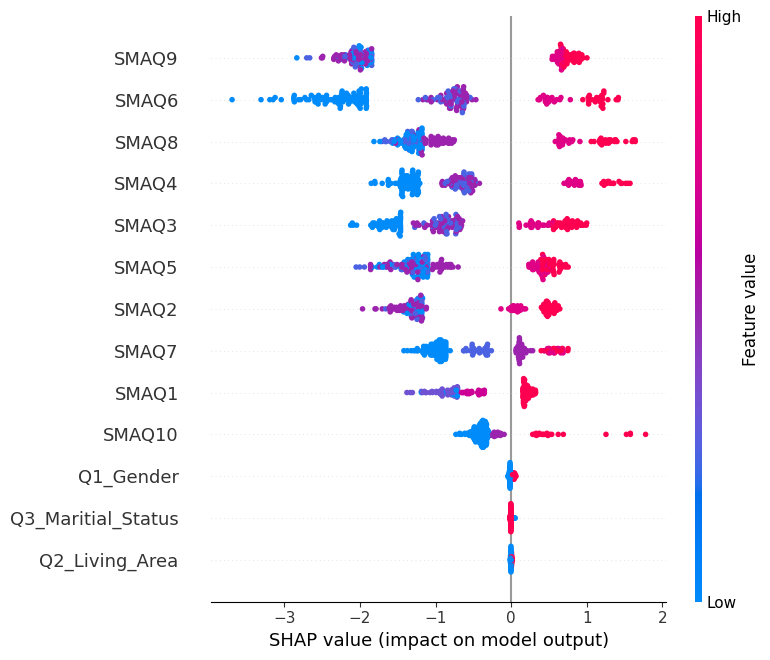

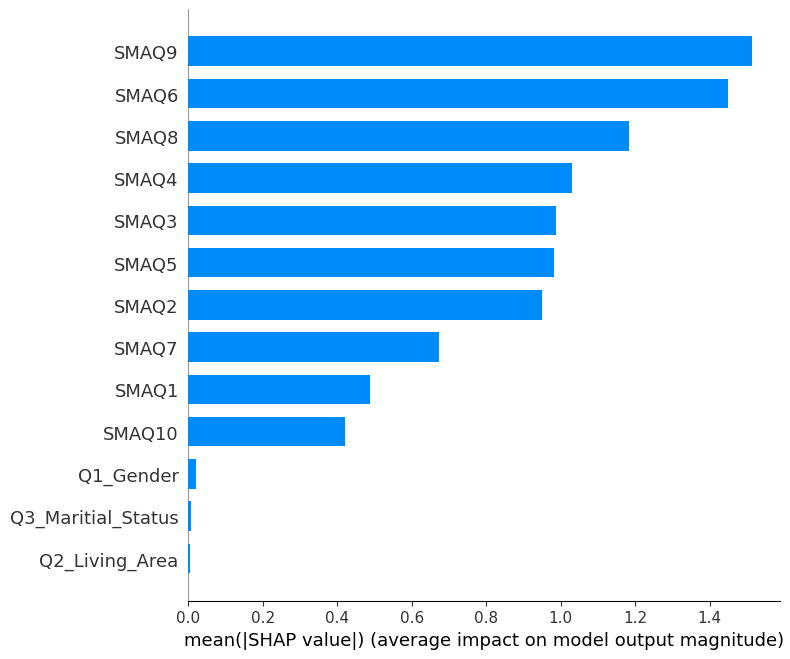


Top Influential Features: ['SMAQ9', 'SMAQ6', 'SMAQ8']


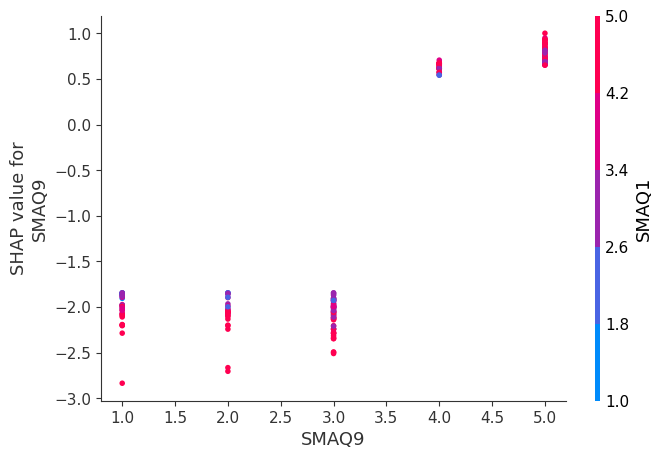

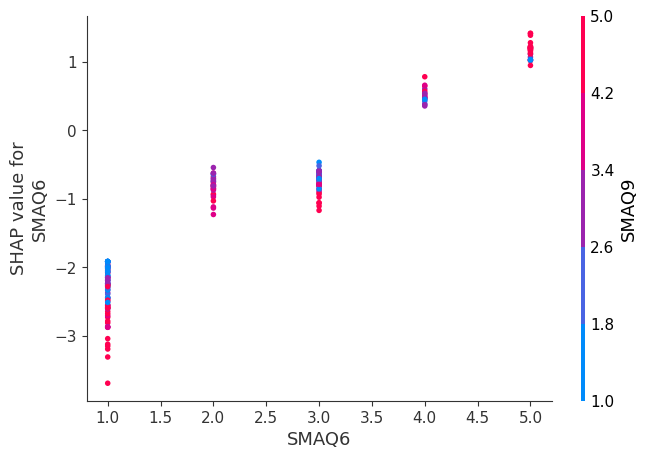

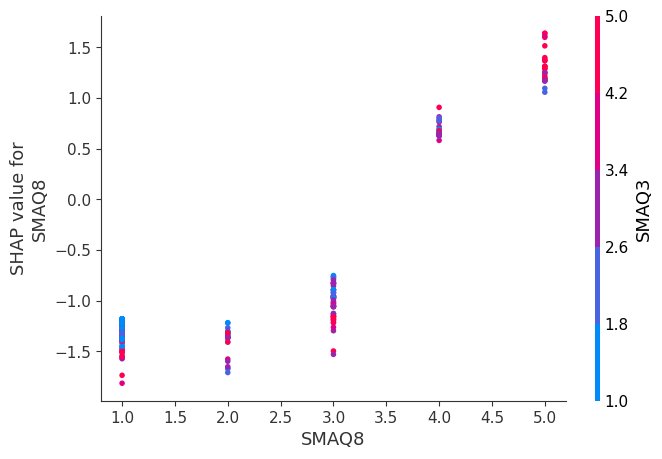

In [ ]:
# ====================================================================
# ✅ SHAP GLOBAL EXPLANATION (Beeswarm + Bar + Dependency)
# ====================================================================

print("\n" + "="*80)
print("🔥 GLOBAL SHAP ANALYSIS — MONOTONIC XGBOOST")
print("="*80)

# --- Prepare samples ---
X_shap = X_test.copy()
if len(X_shap) > 300:
    X_shap = X_shap.sample(300, random_state=42)

X_shap_array = X_shap.values
feature_names = X_shap.columns.tolist()

# --- Create Explainer ---
explainer = shap.TreeExplainer(xgb_monotone)

# --- Compute SHAP values (3D) ---
shap_values = explainer.shap_values(X_shap)

# --- Extract class 2 (High Addiction) ---
high_class = 2  # labels shifted to 0,1,2
shap_values_class2 = shap_values[:, :, high_class]

# --- Validate shapes ---
assert shap_values_class2.shape == X_shap_array.shape

# --- Beeswarm plot ---
shap.summary_plot(
    shap_values_class2, X_shap_array,
    feature_names=feature_names, show=True
)

# --- Bar plot ---
shap.summary_plot(
    shap_values_class2, X_shap_array,
    feature_names=feature_names, plot_type="bar", show=True
)

# --- Dependency plots (Top 3) ---
mean_abs_shap = np.abs(shap_values_class2).mean(axis=0)
top_features_idx = np.argsort(mean_abs_shap)[-3:][::-1]

print("\nTop Influential Features:", [feature_names[i] for i in top_features_idx])

for idx in top_features_idx:
    shap.dependence_plot(
        idx, shap_values_class2, X_shap_array,
        feature_names=feature_names, show=True
)


SHAP Explanation for Sample 0
True class: 1
Predicted class: 1

Feature values:
Q1_Gender             2
Q2_Living_Area        1
Q3_Maritial_Status    2
SMAQ1                 5
SMAQ2                 3
SMAQ3                 3
SMAQ4                 3
SMAQ5                 4
SMAQ6                 3
SMAQ7                 2
SMAQ8                 2
SMAQ9                 3
SMAQ10                5
Name: 224, dtype: int64


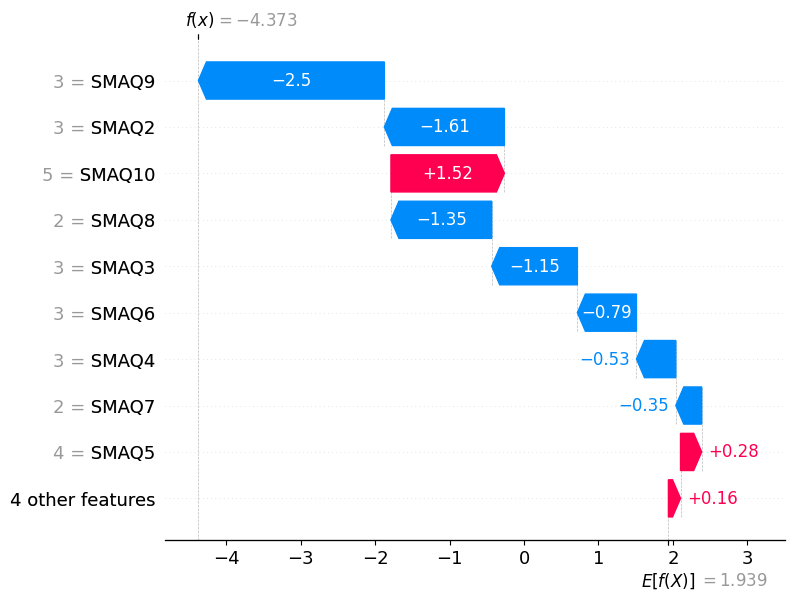

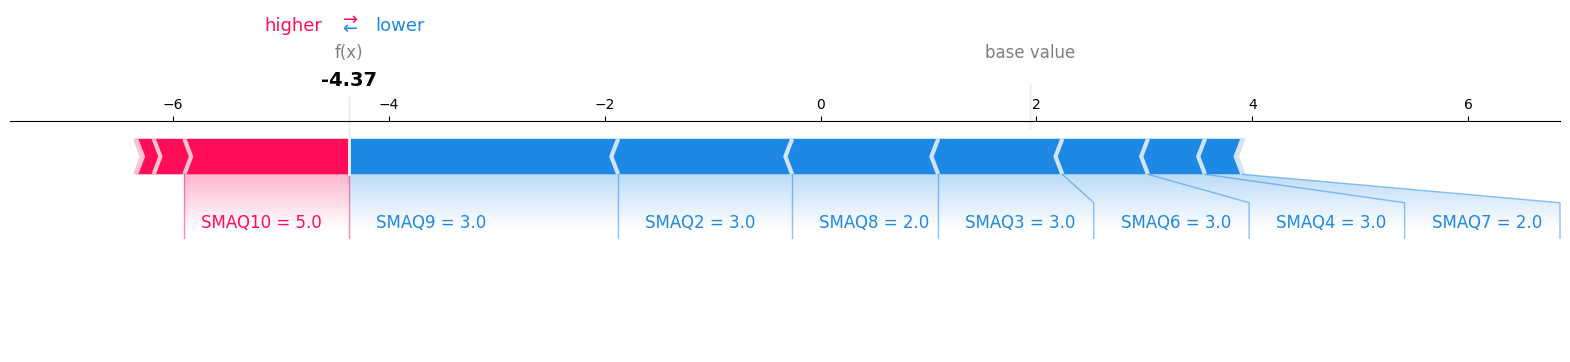


✅ Local SHAP Analysis complete!


In [ ]:
# ====================================================================
# CELL 13: Individual prediction explanation (LOCAL SHAP)
# ====================================================================

sample_idx = 0
print(f"\n{'='*60}")
print(f"SHAP Explanation for Sample {sample_idx}")
print(f"{'='*60}")
print(f"True class: {y_test.iloc[sample_idx]}")
print(f"Predicted class: {xgb_monotone.predict(X_shap.iloc[[sample_idx]])[0]}")
print(f"\nFeature values:")
print(X_shap.iloc[sample_idx])

# Use the class-specific SHAP values you extracted earlier
single_shap = shap_values_class2[sample_idx]

# ✅ WATERFALL plot (local explanation)
shap.waterfall_plot(shap.Explanation(
    values=single_shap,
    base_values=explainer.expected_value[high_class],
    data=X_shap.iloc[sample_idx],
    feature_names=X_shap.columns.tolist()
))

# ✅ FORCE plot
shap.initjs()
shap.force_plot(
    explainer.expected_value[high_class],
    single_shap,
    X_shap.iloc[sample_idx],
    matplotlib=True
)
plt.show()

print("\n✅ Local SHAP Analysis complete!")


🔥 LOCAL SHAP EXPLANATION — SINGLE STUDENT

Explaining sample index: 0
True class: 1
Predicted class: 1


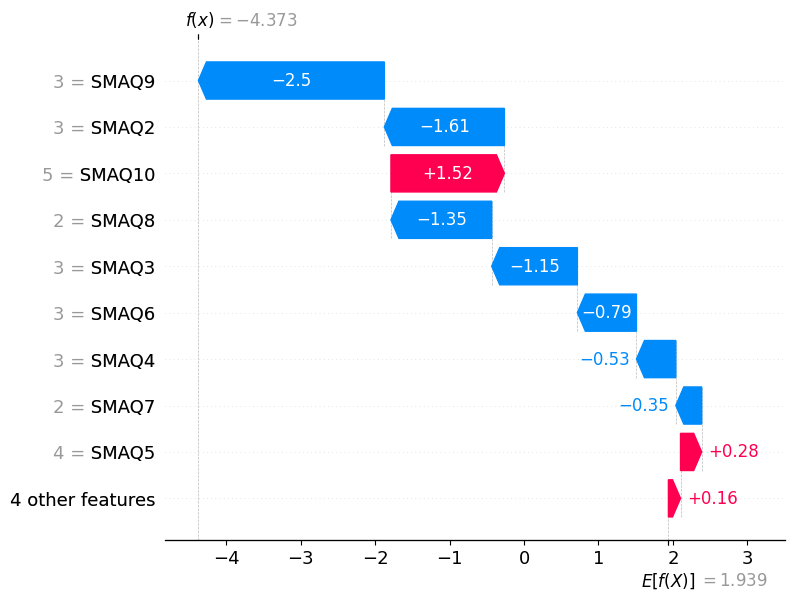

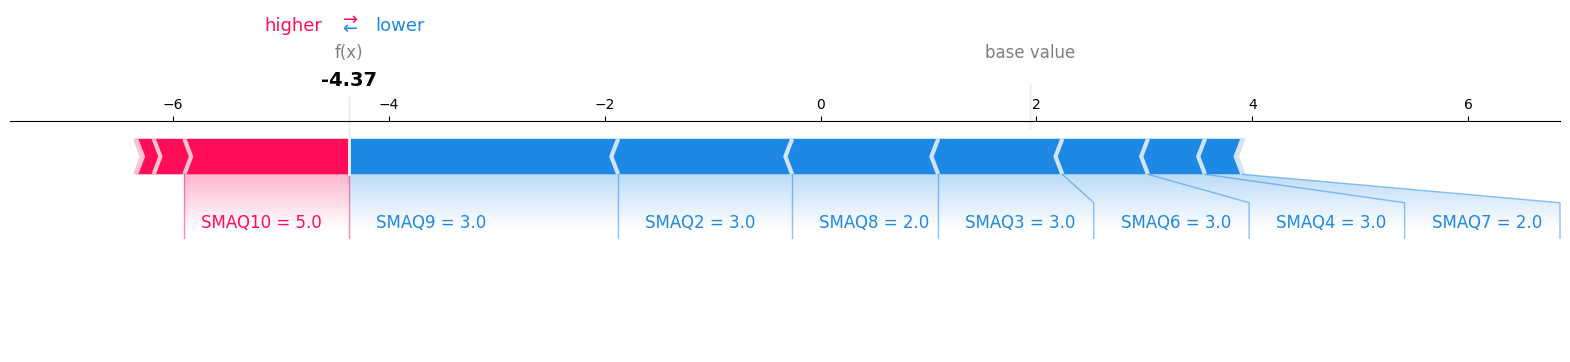


✅ Local SHAP Analysis Complete!


In [ ]:
# ====================================================================
# ✅ SHAP LOCAL EXPLANATION (Waterfall + Force Plot)
# ====================================================================

print("\n" + "="*80)
print("🔥 LOCAL SHAP EXPLANATION — SINGLE STUDENT")
print("="*80)

sample_idx = 0  # choose any

print(f"\nExplaining sample index: {sample_idx}")
print(f"True class: {y_test.iloc[sample_idx]}")
print(f"Predicted class: {xgb_monotone.predict(X_shap.iloc[[sample_idx]])[0]}")

single_shap = shap_values_class2[sample_idx]
single_data = X_shap.iloc[sample_idx]

# --- Waterfall Plot ---
shap.waterfall_plot(
    shap.Explanation(
        values=single_shap,
        base_values=explainer.expected_value[high_class],
        data=single_data,
        feature_names=feature_names
    )
)

# --- Force Plot ---
shap.initjs()
shap.force_plot(
    explainer.expected_value[high_class],
    single_shap,
    single_data,
    matplotlib=True
)
plt.show()

print("\n✅ Local SHAP Analysis Complete!")

# **********************************************************************************************

In [ ]:
# ====================================================================
# Θ-1: Latent Trait θ via PCA (fit on TRAIN only, transform TEST)
# ====================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# List of SMA questions
smaq_cols = [f"SMAQ{i}" for i in range(1, 11)]

# Fit scaler + PCA on TRAIN SMA items (avoid leakage)
scaler_theta = StandardScaler()
pca_theta = PCA(n_components=1, random_state=42)

smaq_train_scaled = scaler_theta.fit_transform(X_train[smaq_cols])
theta_train = pca_theta.fit_transform(smaq_train_scaled).ravel()

# Transform TEST with the same scaler + PCA
smaq_test_scaled = scaler_theta.transform(X_test[smaq_cols])
theta_test = pca_theta.transform(smaq_test_scaled).ravel()

# Append θ at the END (keeps first 3 indices for categorical features)
X_train = X_train.copy()
X_test  = X_test.copy()
X_train["theta_latent"] = theta_train
X_test["theta_latent"]  = theta_test

print("θ added — shapes:", X_train.shape, X_test.shape)
print("θ train mean/std:", float(np.mean(theta_train)), float(np.std(theta_train)))

θ added — shapes: (823, 14) (206, 14)
θ train mean/std: -2.805909952880104e-17 2.048719160450329


In [ ]:
# ====================================================================
# Θ-2: Re-balance with SMOTENC (categoricals unchanged, θ is continuous)
# ====================================================================
from imblearn.over_sampling import SMOTENC

cat_cols = [c for c in X_train.columns if c in ['Q1_Gender','Q2_Living_Area','Q3_Maritial_Status']]
cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]  # still [0,1,2] if θ added at end

print("Categorical columns:", cat_cols, "-> indices:", cat_idx)

sm = SMOTENC(categorical_features=cat_idx, random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts().sort_index().to_dict())
print("After :", y_train_bal.value_counts().sort_index().to_dict())

Categorical columns: ['Q1_Gender', 'Q2_Living_Area', 'Q3_Maritial_Status'] -> indices: [0, 1, 2]
Before: {0: 206, 1: 559, 2: 58}
After : {0: 559, 1: 559, 2: 559}



=== Logistic Regression (with θ) — Classification Report ===
              precision    recall  f1-score   support

           0     0.9808    1.0000    0.9903        51
           1     1.0000    0.9857    0.9928       140
           2     0.9375    1.0000    0.9677        15

    accuracy                         0.9903       206
   macro avg     0.9728    0.9952    0.9836       206
weighted avg     0.9907    0.9903    0.9904       206



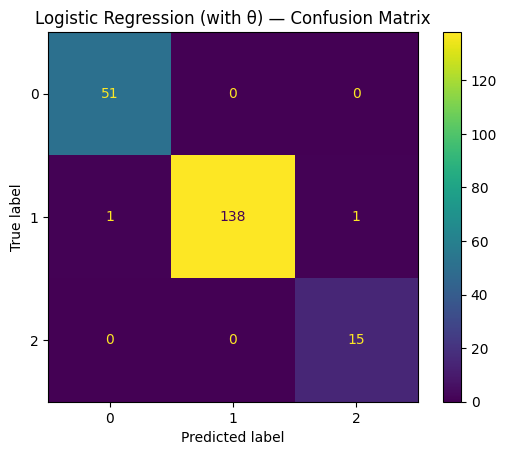

Logistic Regression (with θ) — Macro AUC: 0.9998 | Micro AUC: 0.9998


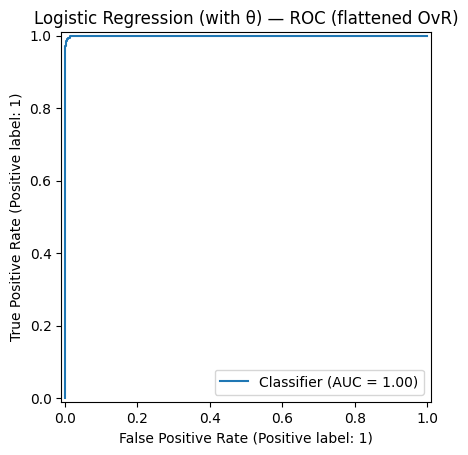


=== XGBoost (Nominal, with θ) — Classification Report ===
              precision    recall  f1-score   support

           0     0.9444    1.0000    0.9714        51
           1     1.0000    0.9786    0.9892       140
           2     1.0000    1.0000    1.0000        15

    accuracy                         0.9854       206
   macro avg     0.9815    0.9929    0.9869       206
weighted avg     0.9862    0.9854    0.9856       206



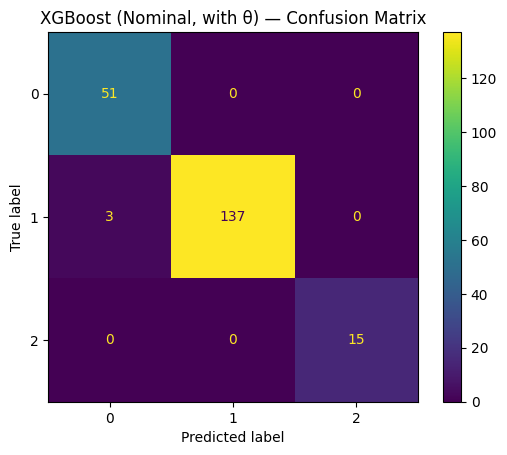

XGBoost (Nominal, with θ) — Macro AUC: 0.9998 | Micro AUC: 0.9996


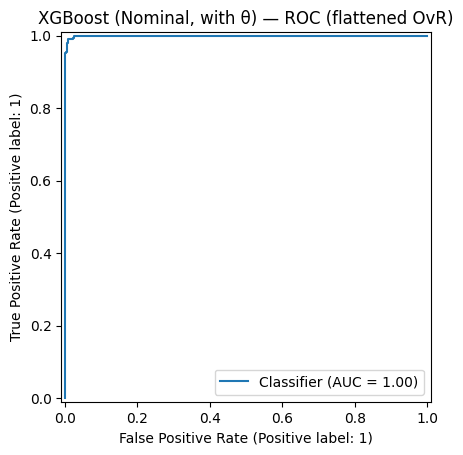


=== Ordinal Logistic (MORD, with θ) — Classification Report ===
              precision    recall  f1-score   support

           0     0.9808    1.0000    0.9903        51
           1     1.0000    0.9857    0.9928       140
           2     0.9375    1.0000    0.9677        15

    accuracy                         0.9903       206
   macro avg     0.9728    0.9952    0.9836       206
weighted avg     0.9907    0.9903    0.9904       206



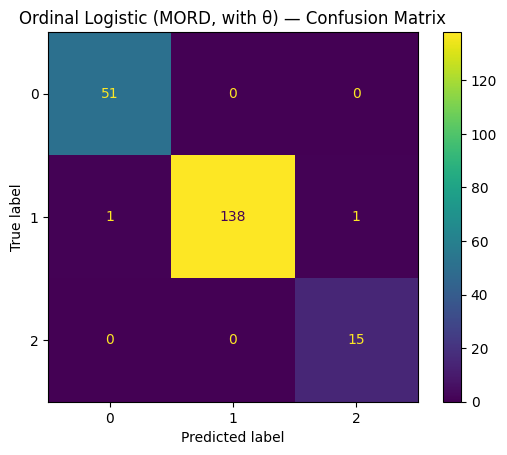

Monotone vector length: 14

=== XGBoost (Monotone, with θ) — Classification Report ===
              precision    recall  f1-score   support

           0     0.9444    1.0000    0.9714        51
           1     1.0000    0.9786    0.9892       140
           2     1.0000    1.0000    1.0000        15

    accuracy                         0.9854       206
   macro avg     0.9815    0.9929    0.9869       206
weighted avg     0.9862    0.9854    0.9856       206



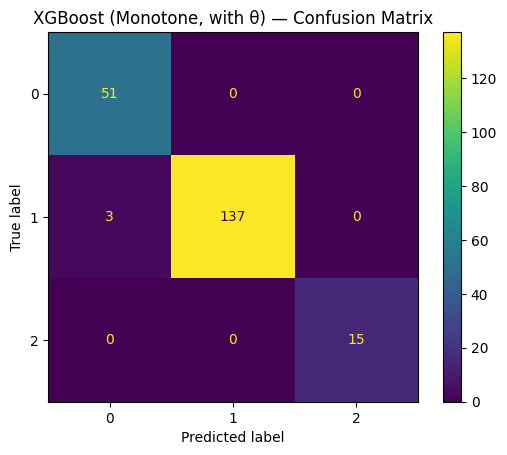

XGBoost (Monotone, with θ) — Macro AUC: 0.9996 | Micro AUC: 0.9994


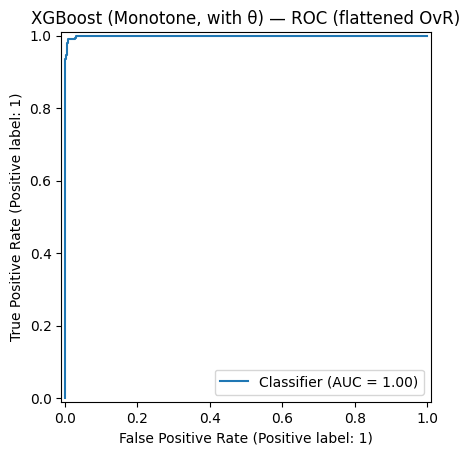

In [ ]:
# ====================================================================
# Θ-3: Retrain models with θ included
# ====================================================================
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import mord
import re
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd

def evaluate_model(clf, X_te, y_te, name="Model", proba_method="predict_proba"):
    y_pred = clf.predict(X_te if not isinstance(X_te, np.ndarray) else X_te)
    print(f"\n=== {name} — Classification Report ===")
    print(classification_report(y_te, y_pred, digits=4))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
    plt.title(f"{name} — Confusion Matrix")
    plt.show()

    if hasattr(clf, proba_method):
        y_score = getattr(clf, proba_method)(X_te)
        y_bin = label_binarize(y_te, classes=sorted(np.unique(y_te)))
        try:
            macro_auc = roc_auc_score(y_bin, y_score, average="macro", multi_class='ovr')
            micro_auc = roc_auc_score(y_bin, y_score, average="micro", multi_class='ovr')
            print(f"{name} — Macro AUC: {macro_auc:.4f} | Micro AUC: {micro_auc:.4f}")
            RocCurveDisplay.from_predictions(y_bin.ravel(), np.asarray(y_score).ravel())
            plt.title(f"{name} — ROC (flattened OvR)")
            plt.show()
        except Exception as e:
            print("AUC calculation skipped:", e)

# 1) Logistic Regression
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', multi_class='auto')
logreg.fit(X_train_bal, y_train_bal)
evaluate_model(logreg, X_test, y_test, name="Logistic Regression (with θ)")

# 2) XGBoost nominal
xgb_nominal = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    max_depth=4, learning_rate=0.07, n_estimators=300,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    random_state=42, tree_method="hist"
)
xgb_nominal.fit(X_train_bal, y_train_bal)
evaluate_model(xgb_nominal, X_test, y_test, name="XGBoost (Nominal, with θ)")

# 3) Ordinal Logistic (MORD)
ord_logit = mord.LogisticAT(alpha=1.0)
ord_logit.fit(X_train_bal.values, y_train_bal.values)
evaluate_model(ord_logit, X_test.values, y_test.values, name="Ordinal Logistic (MORD, with θ)", proba_method="_nope_")

# 4) XGBoost with monotone constraints (SMAQs ↑, demos free, θ free)
mono = []
for c in X_train_bal.columns:
    if re.match(r"SMAQ\d+$", c):
        mono.append(1)     # monotone increasing for item scores
    else:
        mono.append(0)     # no constraint for demos + theta
print("Monotone vector length:", len(mono))

xgb_monotone = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    max_depth=4, learning_rate=0.05, n_estimators=400,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    monotone_constraints="(" + ",".join(map(str, mono)) + ")",
    random_state=42, tree_method="hist"
)
xgb_monotone.fit(X_train_bal, y_train_bal)
evaluate_model(xgb_monotone, X_test, y_test, name="XGBoost (Monotone, with θ)")

In [ ]:
# ====================================================================
# Θ-4: Fairness Analysis — Macro F1 by subgroup (using xgb_monotone)
# ====================================================================
from sklearn.metrics import classification_report

def slice_macro_f1(model, X_te, y_te, col, val):
    idx = X_te[col] == val
    Xs, ys = X_te[idx], y_te[idx]
    if len(ys) == 0: return None
    y_pred = model.predict(Xs)
    rep = classification_report(ys, y_pred, output_dict=True, zero_division=0)
    return rep['macro avg']['f1-score'], len(ys)

print("\n=== FAIRNESS (Macro F1) — XGBoost Monotone (with θ) ===")
for col, vals in {"Q1_Gender":[1,2], "Q2_Living_Area":[1,2]}.items():
    print(f"\n-- {col} --")
    for v in vals:
        out = slice_macro_f1(xgb_monotone, X_test, y_test, col, v)
        if out:
            score, n = out
            print(f"Value {v}: Macro F1={score:.4f} (n={n})")


=== FAIRNESS (Macro F1) — XGBoost Monotone (with θ) ===

-- Q1_Gender --
Value 1: Macro F1=0.9877 (n=136)
Value 2: Macro F1=0.9836 (n=70)

-- Q2_Living_Area --
Value 1: Macro F1=0.9842 (n=136)
Value 2: Macro F1=0.9894 (n=70)


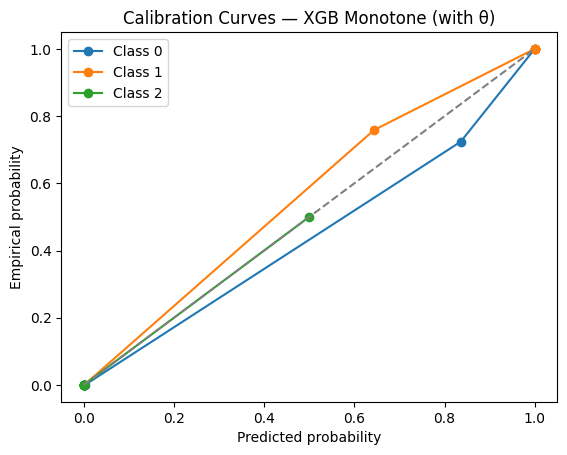

In [ ]:
# ====================================================================
# Θ-5: Calibration Curves — XGBoost Monotone (with θ)
# ====================================================================
from sklearn.calibration import calibration_curve

probs = xgb_monotone.predict_proba(X_test)

plt.figure()
for cls in range(3):
    y_true_cls = (y_test == cls).astype(int)
    y_prob_cls = probs[:, cls]
    frac_pos, mean_pred = calibration_curve(y_true_cls, y_prob_cls, n_bins=7, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', label=f"Class {cls}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("Predicted probability")
plt.ylabel("Empirical probability")
plt.title("Calibration Curves — XGB Monotone (with θ)")
plt.legend()
plt.show()

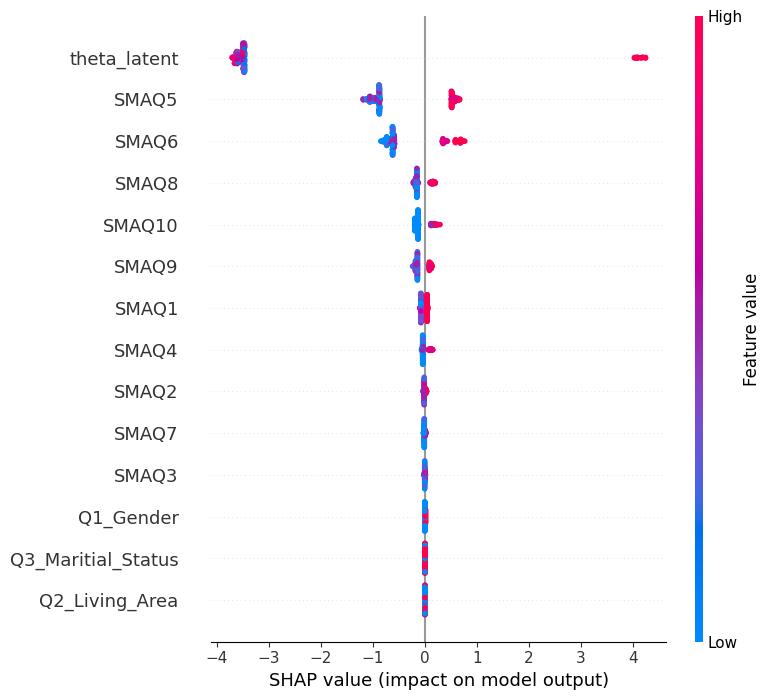

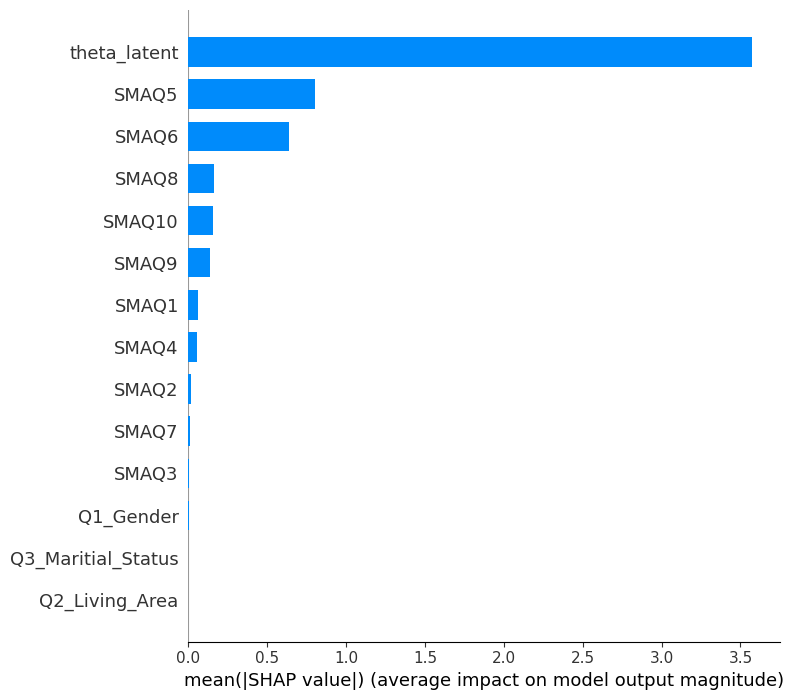

Top features: ['theta_latent', 'SMAQ5', 'SMAQ6']


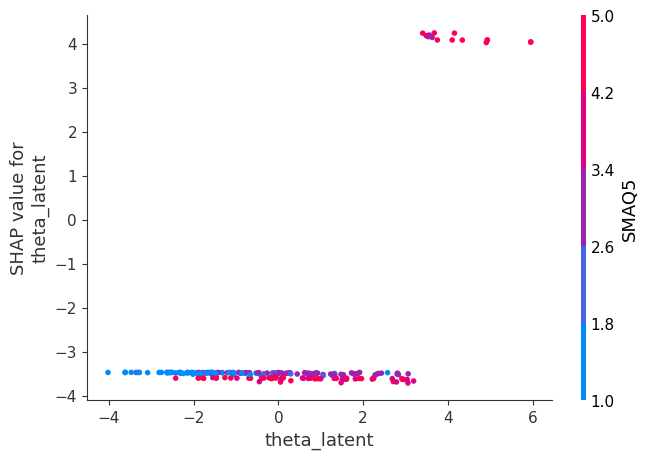

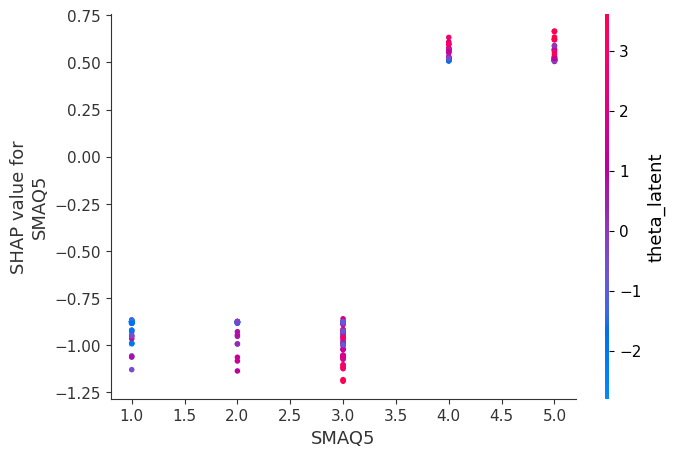

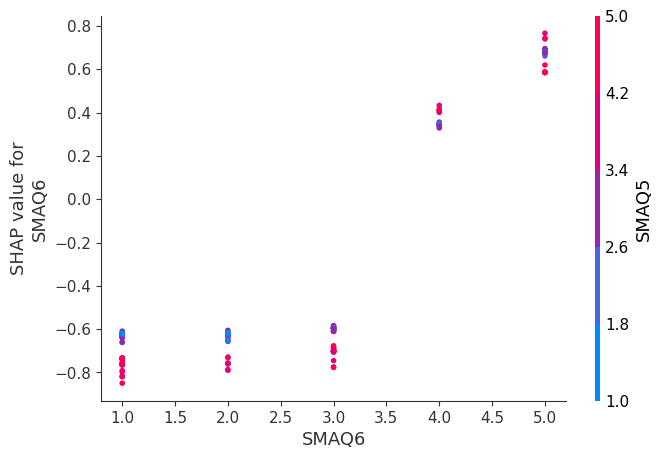

In [ ]:
# ====================================================================
# Θ-6: SHAP — Global (Beeswarm, Bar, Dependency) including θ
# ====================================================================
import shap
import numpy as np

X_shap = X_test.copy()
if len(X_shap) > 300:
    X_shap = X_shap.sample(300, random_state=42)

feature_names = X_shap.columns.tolist()
explainer = shap.TreeExplainer(xgb_monotone)
shap_values = explainer.shap_values(X_shap)           # shape (n, f, 3)

high_class = 2
sv_high = shap_values[:, :, high_class]
assert sv_high.shape == X_shap.values.shape

# Beeswarm
shap.summary_plot(sv_high, X_shap.values, feature_names=feature_names, show=True)
# Bar
shap.summary_plot(sv_high, X_shap.values, feature_names=feature_names, plot_type="bar", show=True)

# Top-3 dependency
mean_abs = np.abs(sv_high).mean(axis=0)
top_idx = np.argsort(mean_abs)[-3:][::-1]
print("Top features:", [feature_names[i] for i in top_idx])
for i in top_idx:
    shap.dependence_plot(i, sv_high, X_shap.values, feature_names=feature_names, show=True)

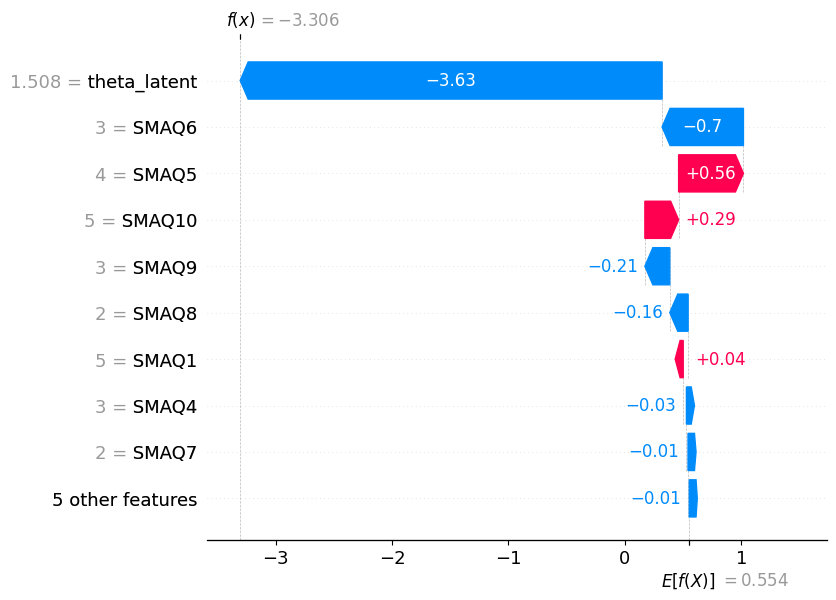

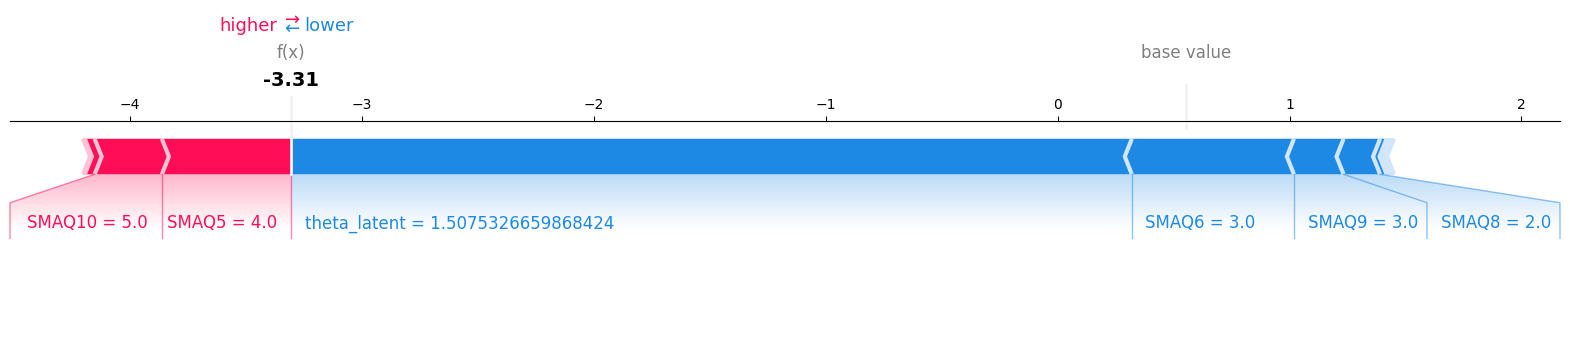

In [ ]:
# ====================================================================
# Θ-7: SHAP — Local (single student) including θ
# ====================================================================
shap.initjs()

sample_idx = 0  # choose any 0..len(X_shap)-1
single_data = X_shap.iloc[sample_idx]
single_sv   = sv_high[sample_idx]

# Waterfall
shap.waterfall_plot(
    shap.Explanation(
        values=single_sv,
        base_values=explainer.expected_value[high_class],
        data=single_data,
        feature_names=feature_names
    )
)

# Force
shap.force_plot(
    explainer.expected_value[high_class],
    single_sv,
    single_data,
    matplotlib=True
)
plt.show()

======================== SMA10 — RESEARCH PIPELINE ========================

    RAW CSV  →  CLEAN/EDA  →  TRAIN/TEST SPLIT
                                   │
                                   ▼
        ┌─────────────── Compute θ from SMAQ1..10 (PCA on TRAIN) ───────────────┐
        │            Append θ to TRAIN and TEST feature sets                    │
        └───────────────────────────────────────────────────────────────────────┘
                                   │
                              SMOTENC on TRAIN
                           (Q1/Q2/Q3 categorical)
                                   │
                                   ▼
        Models →  Logistic  |  XGBoost (nominal)  |  Ordinal Logit  |  XGB Monotone
                                   │
                                   ▼
        Metrics →  Reports, Confusion Matrices, ROC-AUC, CV Macro-F1
                                   │
                                   ├── Fairness slices (Gender / Area)
                                   ├── Calibration curves (per class)
                                   └── SHAP → Global (beeswarm, bar, dependency) + Local (waterfall/force)